# Deeper Regression, Smarter Features

## Import

In [19]:
import pandas as pd
import torch 
import torch.nn as nn
import torch.optim as optim

<a name='1'></a>
## 1 - Multi-Feature Data

This time, you'll be working with a much richer dataset from a `.csv` file, containing records for **100 past deliveries**. Unlike the previous labs where time depended only on distance, this new problem is more complex. The final delivery time is now influenced by multiple input features.

Here's a breakdown of the data you'll be working with:

* **distance_miles**: The total distance of the delivery route in **miles**, represented as a floating point number.

* **time_of_day_hours**: The time the order was **dispatched for delivery** in **hours** on a 24-hour clock, represented as a floating point number (e.g., `16.07` represents a dispatch time shortly after 4:00 PM).

* **is_weekend**: A binary feature representing the day of the week, where `1` indicates a weekend and `0` indicates a weekday.

* **delivery_time_minutes**: This is your **target variable**. It's the total time the delivery took in minutes, represented as a floating point number.

To make the scenario more realistic, this data operates under a few business rules: **deliveries only occur between 8:00 AM (8.0) and 8:00 PM (20.0), and the company does not deliver further than 20 miles**.

<a name='1-1'></a>
### 1.1 - Loading and Exploring the Raw Data

Load and understand your data. 

* Define the file path to your dataset file, `./data_with_features.csv`.
* Use Pandas library to load the dataset from the given file path as a DataFrame, `data_df`, a powerful structure for manipulating and analyzing data.
* Inspect the shape of your data, which will show as **100 rows** (representing 100 deliveries) and **4 columns**.

In [20]:
# Load the dataset into dataframe
data_df=pd.read_csv('./data_with_features.csv')

# Shape of the dataset
print(f"Dataset shape: {data_df.shape} ")

Dataset shape: (100, 4) 


* Inspect first 10 rows of the loaded dataset.

In [21]:
print(f"First 10 dataset entries:\n{data_df.head(10)} ")

First 10 dataset entries:
   distance_miles  time_of_day_hours  is_weekend  delivery_time_minutes
0            1.60               8.20           0                   7.22
1           13.09              16.80           1                  32.41
2            6.97               8.02           1                  17.47
3           10.66              16.07           0                  37.17
4           18.24              13.47           0                  38.36
5            5.74              16.59           0                  29.06
6            8.80              12.25           0                  23.94
7           15.36              11.76           1                  32.40
8            5.35               9.42           0                  17.06
9            2.46              14.44           0                  14.09 


<br>

Now that the data is loaded, it is time to visualize it to understand the relationships between your features and what you are trying to predict.

Create a detailed scatter plot that visualizes all four features at once:

* **X-axis:** distance
* **Y-axis:** delivery time
* **Color:** time of day
* **Filled circle:** weekday
* **Hollow circle:** weekend



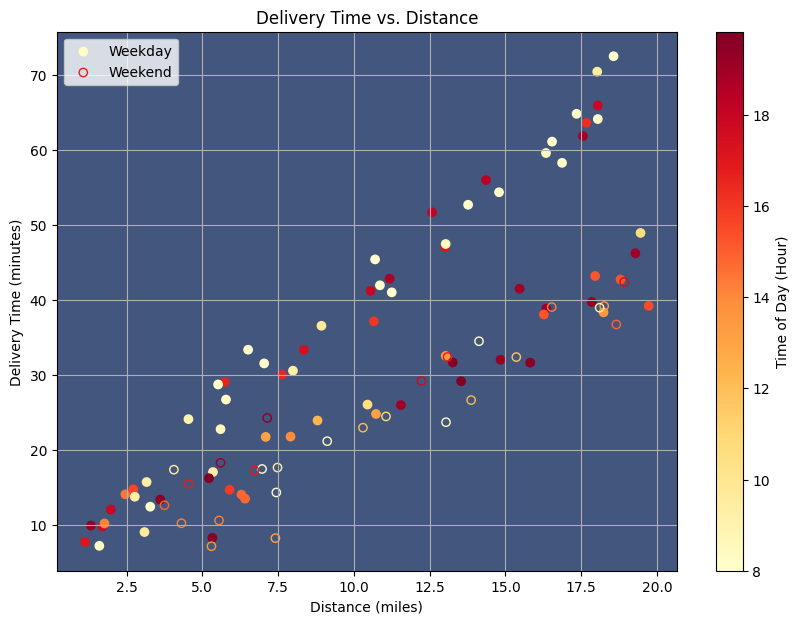

In [22]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(10, 7))  # <-- ADD THIS

weekday = data_df["is_weekend"] == 0
weekend = data_df["is_weekend"] == 1


cmap = plt.colormaps["YlOrRd"]
norm = mpl.colors.Normalize(
    vmin=data_df["time_of_day_hours"].min(),
    vmax=data_df["time_of_day_hours"].max()
)



# Weekday → filled
scatter = ax.scatter(
    data_df.loc[weekday, "distance_miles"],
    data_df.loc[weekday, "delivery_time_minutes"],
    c=data_df.loc[weekday, "time_of_day_hours"],
    cmap=cmap,
    norm=norm,
    label="Weekday"
)

# Weekend → hollow
ax.scatter(
    data_df.loc[weekend, "distance_miles"],
    data_df.loc[weekend, "delivery_time_minutes"],
    facecolors="none",
    edgecolors=cmap(norm(data_df.loc[weekend, "time_of_day_hours"])),
    label="Weekend"
)
# Background
ax.set_facecolor("#43567d")

# Color bar
plt.colorbar(scatter, ax=ax, label="Time of Day (Hour)")

ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Delivery Time (minutes)")
ax.set_title("Delivery Time vs. Distance")

ax.legend()
ax.grid()

plt.show()

<a name='1-2'></a>
### 1.2 - Feature Engineering: Adding Rush Hour

The visualization above reveals an interesting pattern: some deliveries take longer even for the same distance, likely due to peak traffic during **rush hours**.

Instead of hoping the model learns this complex pattern on its own, you can use **feature engineering**. This is a creative step where you apply domain knowledge to make these patterns explicit. You will engineer a new feature that directly tells the model when a delivery falls within a rush hour window.

> This new feature will be `1` if a delivery was dispatched during the morning rush `(8:00 - 10:00 AM)` or the evening rush `(4:00 - 7:00 PM / 16:00 - 19:00)` on a weekday, and `0` otherwise.

Now, you might wonder why rush hour is only being considered on weekdays? This reflects a common real-world pattern. The concept of a "rush hour" is traditionally tied to weekday commuter traffic, which is the pattern that most predictably impacts delivery times on a city-wide scale. This specific pattern disappears on weekends.
Therefore, it's a realistic assumption to make that the primary driver of rush hour delays is the weekday commute.

Before applying logic to the entire dataset, it's a good practice to work with a small sample. This allows you to build and test your function quickly.

* Define the first 5 rows of your `data_df` as a **PyTorch tensor**.
* You use a tensor for this sample because your complete dataset will also be loaded as a tensor. This ensures that the function you build now will work on the full dataset later without any changes.
* This initial tensor contains all the data for each sample delivery.

In [23]:
# Define the 5 rows of data as a single 2D tensor
sample_tensor = torch.tensor([
    # distance, time_of_day, is_weekend, delivery_time
    [1.60,      8.20,        0,          7.22],   # row 1
    [13.09,     16.80,       1,          32.41],  # row 2       
    [6.97,      8.02,        1,          17.47],  # row 3
    [10.66,     16.07,       0,          37.17],  # row 4
    [18.24,     13.47,       0,          38.36]   # row 5
], dtype=torch.float32)

* To create the rush feature, your calculation only depends on the **time of day** and whether it's a **weekday**.
* Use the tensor slicing operation to select only these two columns, ignoring the unnecessary distance and delivery time data for this step.
    * The `time_of_day_hours` is in column index `1`, and `is_weekend` is in column index `2`.

In [24]:
# split into hour and weekend 
sample_hour=sample_tensor[:,1]
sample_weekend=sample_tensor[:,2]

# Print sample hour and sample weekend
print(f"Sample Hours: {sample_hour}\nSample Weekend: {sample_weekend} ")

Sample Hours: tensor([ 8.2000, 16.8000,  8.0200, 16.0700, 13.4700])
Sample Weekend: tensor([0., 1., 1., 0., 0.]) 


<br>

Now that you have the `sample_hours` and `sample_weekends` tensors prepared, you'll use them to build the `rush_hour_feature` function. 

<a name='ex-1'></a>
### Exercise 1 - rush_hour_feature

Implement the `rush_hour_feature` function.

**Your Task:** 

* **Define the individual conditions:**
    * Define `is_morning_rush` to be `True` where the `hours_tensor` is greater than or equal to `8.0` **AND** less than `10.0`.
    * Define `is_evening_rush` to be `True` where the `hours_tensor` is greater than or equal to `16.0` **AND** less than `19.0`.
    * Define `is_weekday` to be `True` where the `weekends_tensor` is equal to `0`.
>
* **Combine the conditions:**
    * Define `is_rush_hour_mask` by combining the three boolean tensors. The logic should be `True` only if it's a weekday **AND** it's either morning rush **OR** evening rush.


In [25]:
def rush_hour_feature(hours_tensor, weekends_tensor):
    # Create individual condition
    is_morning_rush=(hours_tensor>=8.0) & (hours_tensor<10.0)
    is_evening_rush=(hours_tensor>=16.0) & (hours_tensor<19.0)
    is_weekday=weekends_tensor==0

    # Combine condition
    is_rush_hour_mask= is_weekday & (is_morning_rush|is_evening_rush)

    # Convert boolean values into float tensor
    return is_rush_hour_mask.float()

# Call the function to create new feature
rush_hour_for_sample=rush_hour_feature(sample_hour,sample_weekend)

# Print the new engineered feature
print(f"Sample hour: {sample_hour}\nSample weekend: {sample_weekend}\nIs_Rush_hour: {rush_hour_for_sample} ")

Sample hour: tensor([ 8.2000, 16.8000,  8.0200, 16.0700, 13.4700])
Sample weekend: tensor([0., 1., 1., 0., 0.])
Is_Rush_hour: tensor([1., 0., 0., 1., 0.]) 


<a name='1-3'></a>
### 1.3 - Building the Data Preparation Pipeline

Now that you have your feature engineering function, you'll apply it to the data preparation pipeline. The goal is to create a single function that takes the raw pandas DataFrame as input and outputs the final `features` and `targets` tensors that your model will use for training.

This function will perform several key transformations: it will call your `rush_hour_feature()` function to add the new engineered feature, normalize the `distance_miles` and `time_of_day_hours` columns so they are on a comparable scale, and handle all the necessary tensor operations to structure the data correctly.

This process will yield a single `features` tensor and a single `targets` tensor, perfectly formatted for your neural network.

<a name='ex-2'></a>
### Exercise 2 - prepare_data

**Your Task**:

Your task is to implement the core tensor manipulation steps inside the `prepare_data` function. The code for normalization and combining the final features is already provided.

* **Convert DataFrame to Tensor**:
    * Convert the `all_values` (which are extracted from the pandas DataFrame) into a single PyTorch tensor, `full_tensor`.
    * Remember to set the `dtype` to `torch.float32`.
>    
* **Slice into Raw Tensors**:
    * Use tensor slicing to separate `full_tensor` into individual 1D tensors for each column:
        * `raw_distances` (from column index 0)
        * `raw_hours` (from column index 1)
        * `raw_weekends` (from column index 2)
        * `raw_targets` (from column index 3)
>        
* **Create the Engineered Feature**:
    * Call the `rush_hour_feature()` function you just built.
    * Pass your newly sliced `raw_hours` and `raw_weekends` tensors to it.
>    
* **Reshape Feature Tensors**:
    * Use the `.unsqueeze(1)` method on each of your four feature tensors (`raw_distances`, `raw_hours`, `raw_weekends`, and `is_rush_hour_feature`) to add a new dimension.
 

In [26]:
def prepare_data(df):
    # Extract datafram value into array
    all_values=df.values

    # Convert numpy array to tensor and set 32 float bit tensor
    full_tensor=torch.from_numpy(all_values).to(torch.float32)

    # Slice tensor into one feature
    raw_distance=full_tensor[:,0]
    raw_hour=full_tensor[:,1]
    raw_weekend=full_tensor[:,2]
    raw_target=full_tensor[:,3]

    # Feature engineer rush_hour_feature
    is_rush_hour_feature=rush_hour_feature(raw_hour,raw_weekend)

    # Convert 1D tensor to 2D tensor
    distance_col=raw_distance.unsqueeze(1)
    hour_col=raw_hour.unsqueeze(1)
    weekend_col=raw_weekend.unsqueeze(1)
    rush_hour_col=is_rush_hour_feature.unsqueeze(1)

    # Normalized distance and time
    dist_mean,dist_std=distance_col.mean(),distance_col.std()
    hour_mean,hour_std=hour_col.mean(),hour_col.std()

    dist_norm=(distance_col-dist_mean)/dist_std
    hour_norm=(hour_col-hour_mean)/hour_std

    # Combine all 2D feature into a single tensor
    prepared_feature=torch.cat((dist_norm,hour_norm,weekend_col,rush_hour_col),dim=1)

    # Convert target 1D to 2D
    prepared_target=raw_target.unsqueeze(1)

    # Return the values
    return prepared_feature,prepared_target

* **A "features" tensor**: This contains the four columns of input data (distance, time of day, weekend flag, rush hour flag) the model will learn from. Notice how the first two columns have been normalized, and the fourth column is your newly engineered `is_rush_hour` feature.

* **A "targets" tensor**: This contains only the final `delivery_time_minutes`, separated from the input features. This is the value your model will learn to predict.

Run it on the entire dataset to prepare all 100 delivery records for training.

In [27]:
# Convert the CSV file to get final feature and target
features, target=prepare_data(data_df)


###  Checks only Rush / Not Rush

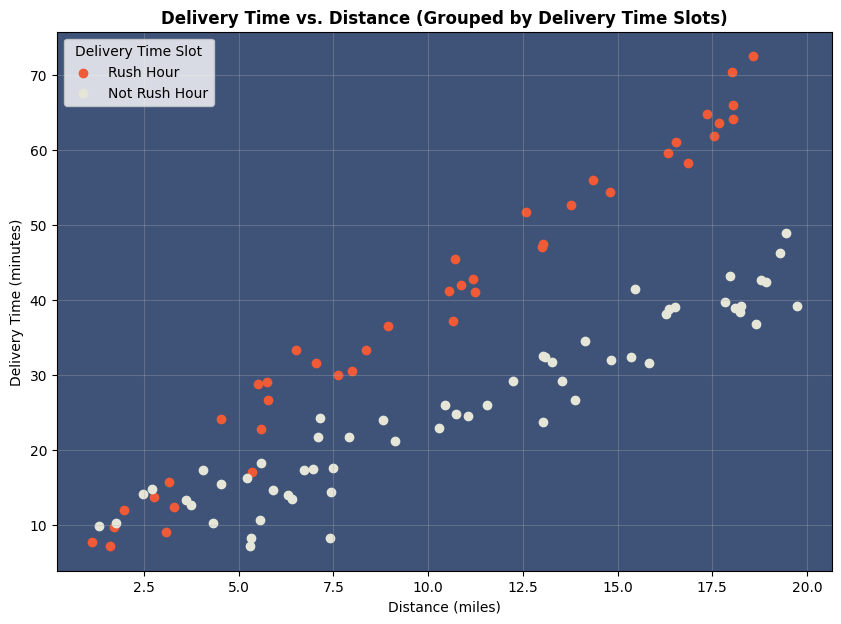

In [28]:
import matplotlib.pyplot as plt

# Original data
distance = data_df["distance_miles"]
delivery_time = data_df["delivery_time_minutes"]

# Create rush-hour feature
hours = torch.tensor(data_df["time_of_day_hours"].values)
weekends = torch.tensor(data_df["is_weekend"].values)

rush_hour = rush_hour_feature(hours, weekends).numpy()

# Masks
rush = rush_hour == 1
not_rush = rush_hour == 0

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.set_facecolor("#3f5278")

ax.scatter(
    distance[rush],
    delivery_time[rush],
    color="#f15a37",
    label="Rush Hour"
)

ax.scatter(
    distance[not_rush],
    delivery_time[not_rush],
    color="#e5e6d8",
    label="Not Rush Hour"
)

ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Delivery Time (minutes)")
ax.set_title(
    "Delivery Time vs. Distance (Grouped by Delivery Time Slots)",
    fontweight="bold"
)

ax.legend(title="Delivery Time Slot")
ax.grid(alpha=0.3)

plt.show()

### Checks: Weekday/Weekend + Rush/Not Rush

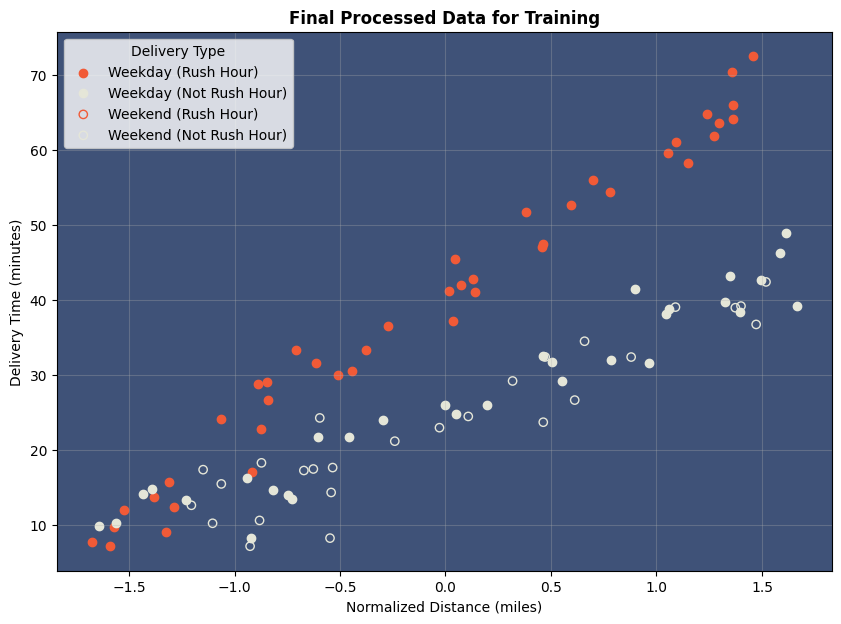

In [29]:
distance_norm = features[:, 0]
weekend = features[:, 2]
rush_hour = features[:, 3]

delivery_time = target[:, 0]

# Masks
weekday_rush = (weekend == 0) & (rush_hour == 1)
weekday_not_rush = (weekend == 0) & (rush_hour == 0)

weekend_rush = (weekend == 1) & (rush_hour == 1)
weekend_not_rush = (weekend == 1) & (rush_hour == 0)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.set_facecolor("#3f5278")

# Weekday Rush → filled orange/red
ax.scatter(
    distance_norm[weekday_rush],
    delivery_time[weekday_rush],
    color="#f15a37",
    label="Weekday (Rush Hour)"
)

# Weekday Not Rush → filled cream
ax.scatter(
    distance_norm[weekday_not_rush],
    delivery_time[weekday_not_rush],
    color="#e5e6d8",
    label="Weekday (Not Rush Hour)"
)

# Weekend Rush → hollow orange/red
ax.scatter(
    distance_norm[weekend_rush],
    delivery_time[weekend_rush],
    facecolors="none",
    edgecolors="#f15a37",
    label="Weekend (Rush Hour)"
)

# Weekend Not Rush → hollow cream
ax.scatter(
    distance_norm[weekend_not_rush],
    delivery_time[weekend_not_rush],
    facecolors="none",
    edgecolors="#e5e6d8",
    label="Weekend (Not Rush Hour)"
)

ax.set_xlabel("Normalized Distance (miles)")
ax.set_ylabel("Delivery Time (minutes)")
ax.set_title("Final Processed Data for Training", fontweight="bold")

ax.legend(title="Delivery Type")
ax.grid(alpha=0.3)

plt.show()

<a name='2'></a>
## 2 - Building the Neural Network

With your data pipeline complete, you are now ready for the next major stage: **building the model.**

Since your problem now involves multiple features, you'll need a more sophisticated architecture than the ones you had seen before. You will build a neural network with two hidden layers to capture the complex relationships between all your input features.

<a name='ex-3'></a>
### Exercise 3 - init_model

Implement the `init_model` function, to define the model architecture, the optimizer, and the loss function.

**Your Task:**

* **Define the Model Architecture**:
    * Define a `model` using `nn.Sequential`.
    * The model **should only** have three `nn.Linear` layers, each followed by a `nn.ReLU()` activation function, except for the last one.
        * **Input Layer**: An `nn.Linear` layer that accepts **4 input features** and outputs **64 features**.
        * **Hidden Layer**: An `nn.Linear` layer that takes the **64 features** from the previous layer and outputs **32 features**.
        * **Output Layer**: A final `nn.Linear` layer that takes the **32 features** from the hidden layer and produces a **single output** value.
>        
* **Define the Optimizer**:
    * Define the `optimizer` as **Stochastic Gradient Descent (SGD)**. You need to pass it the model's parameters (`model.parameters()`) and set the learning rate (`lr`) to `0.01`.
>
* **Define the Loss Function**:
    * Define the `loss_function` as **Mean Squared Error (MSE)**.
 

In [35]:
def init_model():
    # Set random seed for reproducibility
    torch.manual_seed(41)

    # Define model 
    model=nn.Sequential    (

    # first layer with relu activation function
    nn.Linear(4,64),nn.ReLU(),

    # Second  layer with relu activation function
    nn.Linear(64,32),nn.ReLU(),

    # Output layer
    nn.Linear(32,1)
    )

    # Define optimizer
    optimizer=optim.SGD(model.parameters(),lr=0.01)

    # Define loss function
    loss_function=nn.MSELoss()

    # Return 
    return model,optimizer,loss_function

# Call function and print the model 
model,optimizer,loss_function=init_model()
print(f"Model Architecture: \n{model}\n{'-'*70}\nOptimizer: {optimizer}\n{'-'*70}%%!\nLoss function: \n{loss_function} ")

Model Architecture: 
Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
----------------------------------------------------------------------
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
----------------------------------------------------------------------%%!
Loss function: 
MSELoss() 


<a name='3'></a>
## 3 - Training the Model

With your data prepared and your model architecture defined, it's time for the most important stage: **training**. 

<a name='ex-4'></a>
### Exercise 4 - train_model

Implement the complete training loop inside the `train_model` function.

**Your Task:**

* **Initialize your model and tools:**
    * Start by calling the `init_model()` function you built earlier to get your `model`, `optimizer`, and `loss_function`.
>    
* **Loop through the epochs:**
    * Create a `for` loop that iterates from 0 up to the number of `epochs` provided.
>    
* **Implement the training steps inside the loop:**
    * Perform these five steps **in order** on each iteration:
        * **Forward Pass**: Pass your `features` tensor into the `model` to get its predictions.
        * **Calculate Loss**: Use your `loss_function` to compare the model's predictions with the actual `targets`.
        * **Zero Gradients**: Zero the gradients on the `optimizer` from the previous iteration.
        * **Backward Pass**: Perform the backward pass on your `loss` to calculate the new gradients.
        * **Update Weights**: Take a step with the `optimizer` to update the model's parameters.
 

In [39]:
def train_model(features, targets, epochs):
    # Empty list to store loss
    losses=[]

    # call init model 
    model,optimizer,loss_function=init_model()

    # Train the model for epoch
    for epoch in range(epochs):
        # forward pass: make prediction
        output=model(features)
        
        # calculate loss
        loss=loss_function(output,targets)
        
        # Zero the gradient
        optimizer.zero_grad()
        
        # Backward pass: calculate gradient
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        # Track loss for every 500 epoch
        if (epoch+1)%500==0:
            losses.append(loss.item())
            print(f"Epoch {epoch+1} Loss: {loss.item():.4f} ")

    # Return
    return model,losses



# Train the model for 30,000 epochs

In [41]:
model, loss = train_model(features, target, 30000)

Epoch 500 Loss: 11.0650 
Epoch 1000 Loss: 7.2272 
Epoch 1500 Loss: 6.3917 
Epoch 2000 Loss: 5.5839 
Epoch 2500 Loss: 5.5716 
Epoch 3000 Loss: 5.1481 
Epoch 3500 Loss: 4.7413 
Epoch 4000 Loss: 4.4038 
Epoch 4500 Loss: 4.0155 
Epoch 5000 Loss: 4.4172 
Epoch 5500 Loss: 4.6053 
Epoch 6000 Loss: 3.1926 
Epoch 6500 Loss: 2.2234 
Epoch 7000 Loss: 2.4102 
Epoch 7500 Loss: 2.9182 
Epoch 8000 Loss: 3.2000 
Epoch 8500 Loss: 2.5188 
Epoch 9000 Loss: 2.0346 
Epoch 9500 Loss: 2.0688 
Epoch 10000 Loss: 1.7258 
Epoch 10500 Loss: 1.4979 
Epoch 11000 Loss: 1.9381 
Epoch 11500 Loss: 1.3317 
Epoch 12000 Loss: 1.4729 
Epoch 12500 Loss: 2.7202 
Epoch 13000 Loss: 1.2567 
Epoch 13500 Loss: 1.1859 
Epoch 14000 Loss: 1.1426 
Epoch 14500 Loss: 3.2677 
Epoch 15000 Loss: 1.1656 
Epoch 15500 Loss: 1.0323 
Epoch 16000 Loss: 1.0057 
Epoch 16500 Loss: 0.8886 
Epoch 17000 Loss: 1.5180 
Epoch 17500 Loss: 0.9581 
Epoch 18000 Loss: 1.0894 
Epoch 18500 Loss: 0.7395 
Epoch 19000 Loss: 1.3520 
Epoch 19500 Loss: 0.9565 
Epoch

<a name='4'></a>
## 4 - Evaluating Model Performance

Now that your model is trained, it's time to evaluate its performance. A simple yet powerful way to do this for a regression task is to plot the model's predictions against the actual target values.

* First, use your trained `model` to get predictions for the entire dataset.
* Then, create a scatter plot, **Actual Delivery Times (x-axis) vs. Predicted Delivery Times (y-axis)**.
* If the model is accurate, the points on the plot should form a tight cluster along a straight diagonal line.
    * The closer the points are to this line, the better your model's predictions are.
    
Let's see how well your model did!

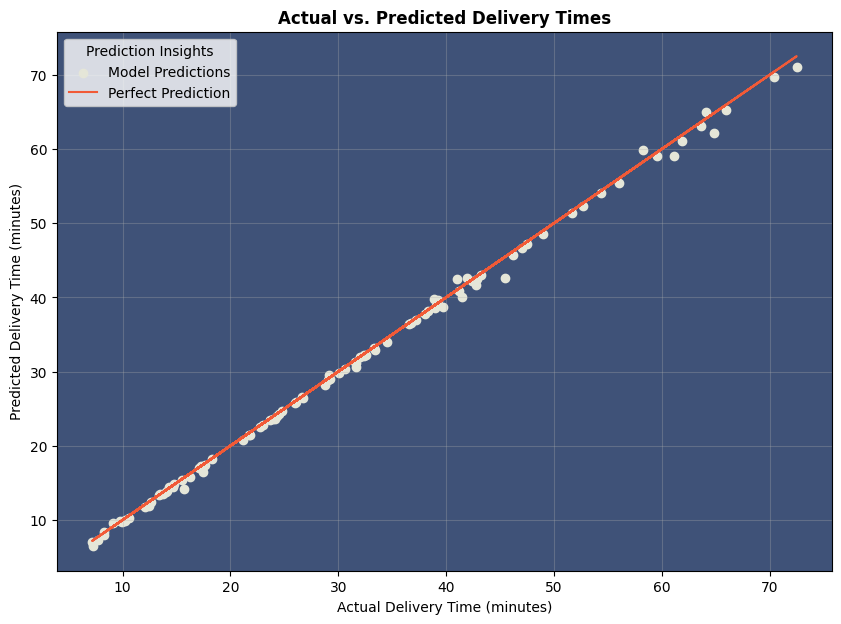

In [43]:
import matplotlib.pyplot as plt

# Make predictions
with torch.no_grad():
    predicted_outputs = model(features)

# Convert tensors to numpy
actual = target.squeeze().numpy()
predicted = predicted_outputs.squeeze().numpy()

# Create plot
fig, ax = plt.subplots(figsize=(10, 7))

# Background
ax.set_facecolor("#3f5278")

# Plot model predictions
ax.scatter(
    actual,
    predicted,
    color="#e5e6d8",
    label="Model Predictions"
)

# Perfect prediction line
ax.plot(
    actual,
    actual,
    color="#f15a37",
    label="Perfect Prediction"
)

# Labels
ax.set_xlabel("Actual Delivery Time (minutes)")
ax.set_ylabel("Predicted Delivery Time (minutes)")
ax.set_title("Actual vs. Predicted Delivery Times", fontweight="bold")

ax.legend(title="Prediction Insights")
ax.grid(alpha=0.3)

plt.show()

<br>

The results look fantastic!

As you can see in the "Actual vs. Predicted" plot, the model's predictions (the light gray points) form a very tight cluster that follows the "Perfect Prediction" line almost exactly. This indicates that your model has learned the patterns in the data very well and is making highly accurate predictions.

A result like this in a real-world project would be considered a great success. With your model's performance evaluated, you're ready for the final step: using it to make a prediction on new, unseen data.

<a name='5'></a>
## 5 - Making a New Prediction

With a well-trained and evaluated model, you've reached the final and most practical stage: **prediction**. It's time to use your model to make a prediction on new, unseen data. 

* Define a new delivery scenario by setting the distance, time of day, and whether it's a weekend.

**Note on Business Rules:**
Remember the constraints of the delivery service when setting your values:
* **Distance**: Must be less than or equal to `20` miles.
* **Time**: Must be between `8.0` (8:00 AM) and `20.0` (8:00 PM).
* **Weekend**: Can be set using `True`/`False` or `1`/`0`.

In [45]:
# Set distance for the delivery in miles
distance_miles = 20 
# Set time of day in 24-hour format (e.g., 9.5 for 9:30 AM)
time_of_day_hours = 9.0
# Use True/False or 1/0 to indicate if it's a weekend
is_weekend = True

# Convert the raw inputs into a 2D tensor for the model
raw_input_tensor = torch.tensor([[distance_miles, time_of_day_hours, is_weekend]], dtype=torch.float32)

In [48]:
def prediction(model, data_df, raw_input_tensor, rush_hour_feature):

    # Extract new input
    distance = raw_input_tensor[:, 0]
    hour = raw_input_tensor[:, 1]
    weekend = raw_input_tensor[:, 2]

    # Create rush-hour feature
    rush_hour = rush_hour_feature(hour, weekend)

    # Get mean and std from original training data
    distance_mean = data_df["distance_miles"].mean()
    distance_std = data_df["distance_miles"].std()

    hour_mean = data_df["time_of_day_hours"].mean()
    hour_std = data_df["time_of_day_hours"].std()

    # Normalize new distance and hour
    distance_norm = (distance - distance_mean) / distance_std
    hour_norm = (hour - hour_mean) / hour_std

    # Combine all 4 features
    prepared_input = torch.stack(
        (distance_norm, hour_norm, weekend, rush_hour),
        dim=1
    )

    # Make prediction
    with torch.no_grad():
        predicted_time = model(prepared_input)

    return predicted_time
predicted_time = prediction(
    model,
    data_df,
    raw_input_tensor,
    rush_hour_feature
)

# Convert tensors to normal Python values
distance_value = raw_input_tensor[0, 0].item()
hour_value = raw_input_tensor[0, 1].item()
weekend_value = raw_input_tensor[0, 2].item()

prediction_value = predicted_time.item()

# Check rush hour
rush = rush_hour_feature(
    raw_input_tensor[:, 1],
    raw_input_tensor[:, 2]
).item()

# Convert values to readable text
day_text = "Weekend" if weekend_value == 1 else "Weekday"
rush_text = "Yes" if rush == 1 else "No"

# Print formatted output
print("+----------------------------------------------------------+")
print("|                    Model Prediction                      |")
print("+-----------------------------------+----------------------+")
print(f"| Time of the Week                  | {day_text:<20} |")
print(f"| Distance                          | {distance_value:<5.1f} miles          |")
print(f"| Time                              | {hour_value:02.0f}:00                |")
print(f"| Is this considered a rush hour?   | {rush_text:<20} |")
print("+-----------------------------------+----------------------+")
print(f"| Estimated Delivery Time           | {prediction_value:.2f} minutes        |")
print("+-----------------------------------+----------------------+")

+----------------------------------------------------------+
|                    Model Prediction                      |
+-----------------------------------+----------------------+
| Time of the Week                  | Weekend              |
| Distance                          | 20.0  miles          |
| Time                              | 09:00                |
| Is this considered a rush hour?   | No                   |
+-----------------------------------+----------------------+
| Estimated Delivery Time           | 37.89 minutes        |
+-----------------------------------+----------------------+
